In [ ]:
!pip install hpsv3

In [ ]:
from datasets import load_dataset

ds1 = load_dataset("weathon/aas_benchmark-nano-banana")
# ds2 = load_dataset("weathon/aas_benchmark-qwen_image")
# ds3 = load_dataset("weathon/aas_benchmark-gpt-image-mini")
# ds4 = load_dataset("weathon/aas_benchmark-gpt-image-mini-high")
# ds5 = load_dataset("weathon/aas_benchmark-seeddream4")
ds6 = load_dataset("weathon/aas_benchmark-stable_diffusion_xl")
# ds7 = load_dataset("weathon/aas_benchmark-stable_diffusion_1.5")
ds8 = load_dataset("weathon/aas_benchmark-flux_krea")
ds8 = load_dataset("weathon/aas_benchmark-flux_dev")
ds9 = load_dataset("weathon/aas_benchmark-grpo_flux")
ds10 = load_dataset("weathon/aas_benchmark-playground")
ds11 = load_dataset("weathon/aas_benchmark-sd3_medium_grpo")
ds12 = load_dataset("weathon/aas_benchmark-sd3_medium_grpo_geneval")
ds12 = load_dataset("weathon/aas_benchmark-stable_diffusion_3.5_medium")
ds12 = load_dataset("weathon/aas_benchmark-sd3_medium_grpo")
ds12 = load_dataset("weathon/aas_benchmark-dance_flux")
# ds13 = load_dataset("weathon/aas_benchmark-stable_diffusion_3.5_large")
# ds13 = load_dataset("weathon/aas_benchmark-stable_diffusion_3.5_large")

In [ ]:
# concate the dataset
from datasets import concatenate_datasets

ds = concatenate_datasets([ds1["train"], ds2["train"], ds3["train"], ds4["train"], ds5["train"], ds6["train"], ds7["train"], ds8["train"], ds9["train"], ds10["train"], ds11["train"], ds12["train"], ds13["train"]])

In [ ]:
ds.push_to_hub("weathon/aas_benchmark-all", private=True)

Uploading the dataset shards:   0%|          | 0/13 [00:00<?, ? shards/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

...

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/weathon/aas_benchmark-all/commit/1ee9abd2a805f644ab14a560a194b03d58eb8d6d', commit_message='Upload dataset', commit_description='', oid='1ee9abd2a805f644ab14a560a194b03d58eb8d6d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/weathon/aas_benchmark-all', endpoint='https://huggingface.co', repo_type='dataset', repo_id='weathon/aas_benchmark-all'), pr_revision=None, pr_num=None)

In [ ]:
ds

Dataset({
    features: ['index', 'prompt_original', 'prompt_distorted', 'selected_dims', 'hpsv2_original', 'hpsv2_distorted', 'rater_scores', 'llm_original_reasoning', 'llm_original_main_concepts', 'llm_original_special_effects', 'llm_distorted_reasoning', 'llm_distorted_main_concepts', 'llm_distorted_special_effects', 'image_original', 'image_distorted', 'model'],
    num_rows: 2600
})

In [ ]:
ds = ds.remove_columns(["image_distorted", "image_original"])

In [ ]:
import json
import tqdm
process_row = lambda x: sum(i["distorted"] for i in json.loads(x["rater_scores"]).values())

aas = []
for i in tqdm.tqdm(ds):
  aas.append(process_row(i))

100%|██████████| 1800/1800 [00:00<00:00, 5486.68it/s]


In [ ]:
ds

Dataset({
    features: ['index', 'prompt_original', 'prompt_distorted', 'selected_dims', 'hpsv2_original', 'hpsv2_distorted', 'rater_scores', 'llm_original_reasoning', 'llm_original_main_concepts', 'llm_original_special_effects', 'llm_distorted_reasoning', 'llm_distorted_main_concepts', 'llm_distorted_special_effects', 'model'],
    num_rows: 1800
})

(array([2.900e+02, 5.800e+01, 2.500e+01, 5.400e+01, 1.900e+01, 1.000e+00,
        4.600e+01, 1.900e+01, 2.610e+02, 1.027e+03]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

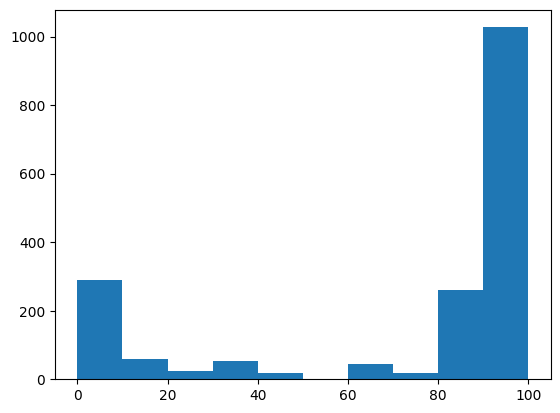

In [ ]:
import pylab

# before
pylab.hist(ds["llm_distorted_special_effects"])

In [ ]:
import numpy as np
np.sum(np.array(ds["llm_distorted_special_effects"])<50)

np.int64(446)

In [ ]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr
import pandas as pd


diff_var1 = np.array(ds['llm_distorted_special_effects']) - np.array(ds['llm_original_special_effects'])
diff_var2 = np.array(ds['hpsv2_distorted']) - np.array(ds['hpsv2_original'])

correlation_coefficient, p_value = spearmanr(diff_var1, diff_var2)

print(correlation_coefficient)
print(p_value)

-0.12821993158088077
4.796947264838358e-08


(array([  2.,   1.,  18.,  54., 136., 108.,  36.,   9.,   0.,   2.]),
 array([-0.1842041 , -0.14992676, -0.11564941, -0.08137207, -0.04709473,
        -0.01281738,  0.02145996,  0.0557373 ,  0.09001465,  0.12429199,
         0.15856934]),
 <BarContainer object of 10 artists>)

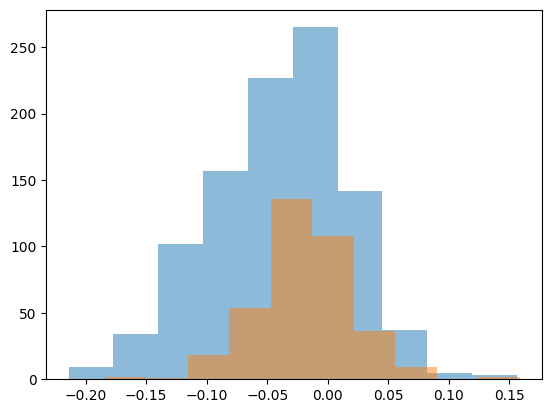

In [ ]:
pylab.hist(diff_var2[diff_var1>85], alpha=0.5)
pylab.hist(diff_var2[diff_var1<20], alpha=0.5)

In [ ]:
import scipy.stats as stats
print(stats.ttest_ind(diff_var2[diff_var1>85], diff_var2[diff_var1<20], equal_var = False))

TtestResult(statistic=np.float64(-8.339879749257218), pvalue=np.float64(2.7129870495028167e-16), df=np.float64(915.4163443594607))


(array([273.,  18.,  51.,   4.,  26.,   3.,  51.,   3.,  16.,   3.,   2.,
         10.,  39.,  11.,  19.,  10.,  13., 250., 747.]),
 array([ 0.,  5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60.,
        65., 70., 75., 80., 85., 90., 95.]),
 <BarContainer object of 19 artists>)

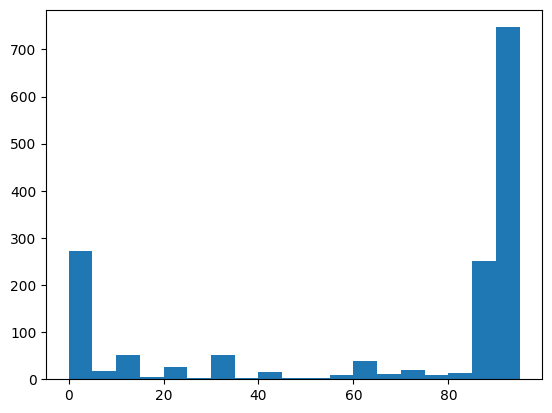

In [ ]:
pylab.hist(diff_var1, bins=np.arange(0, 100, 5))

In [ ]:
group1 = diff_var2[diff_var1 > 85]
group2 = diff_var2[diff_var1 < 20]

mean1 = np.mean(group1)
mean2 = np.mean(group2)
std1 = np.std(group1, ddof=1)
std2 = np.std(group2, ddof=1)

n1 = len(group1)
n2 = len(group2)
pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))


cohens_d = (mean1 - mean2) / pooled_std
cohens_d

np.float64(-0.43937760905543893)

In [ ]:
ds = ds.map(lambda x: x|{"delta_llm_special_effect": x["llm_distorted_special_effects"] - x["llm_original_special_effects"]}, batched=False)

Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

In [ ]:
ds = ds.map(lambda x: x|{"delta_hps": 100 * (x["hpsv2_distorted"] - x["hpsv2_original"])})

Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

In [ ]:
pd.DataFrame(ds).groupby("model")[["delta_llm_special_effect", "delta_hps"]].mean()

,delta_llm_special_effect,delta_hps
model,,
flux_krea,69.330,-1.688171
gpt-image-mini,87.635,-7.678711
gpt-image-mini-high,89.225,-7.810059
grpo_flux,54.340,-1.071777
nano-banana,84.205,-3.499054
qwen_image,80.610,-1.649658
seeddream4,83.380,-2.192871
stable_diffusion_1.5,24.425,-2.100250
stable_diffusion_xl,42.700,-1.603577
